In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st

In [2]:
o = pd.read_excel('OptoJumpSorted.xlsx', sheet_name='GeneralSbs')
ost = pd.read_excel('OptoJumpSorted.xlsx', sheet_name='GeneralSt')
tf = pd.read_excel('OptoJumpSorted.xlsx', sheet_name='TFlight')
tc = pd.read_excel('OptoJumpSorted.xlsx', sheet_name='TContact')
e = pd.read_excel('OptoJumpSorted.xlsx', sheet_name='Elevation')
pw = pd.read_excel('OptoJumpSorted.xlsx', sheet_name='Power')
pc = pd.read_excel('OptoJumpSorted.xlsx', sheet_name='Pace')
rsi = pd.read_excel('OptoJumpSorted.xlsx', sheet_name='RSI')
wpx = pd.read_excel('OptoJumpSorted.xlsx', sheet_name='WPX')
wpy = pd.read_excel('OptoJumpSorted.xlsx', sheet_name='WPY')
sw = pd.read_excel('OptoJumpSorted.xlsx', sheet_name='StepWidth')
nj = pd.read_excel('OptoJumpSorted.xlsx', sheet_name='NJ')
d = pd.read_excel('OptoJumpSorted.xlsx', sheet_name='Distance')
tt = pd.read_excel('OptoJumpSorted.xlsx', sheet_name='TTotal')
tp = pd.read_excel('OptoJumpSorted.xlsx', sheet_name='TPoints')

In [3]:
#swap
tt.loc[:40, 'Test'] = 'final'
tt.loc[40:, 'Test'] = 'initial'

In [4]:
df_list = [tf, tc, e, pw, pc, rsi, wpx, wpy, sw, nj, d, tp]
melt_df_list = []
for df in df_list:
    df.loc[:,'Test'] = tt.loc[:,'Test']    #swap
    melt_df_list = melt_df_list + [pd.melt(df, id_vars=['Name','Test','Group','Sex','NJumps','Mean'], 
                                   value_vars=range(1,170), var_name='Jump', value_name='val')]

In [5]:
melt_df_list_timed = []
for df in melt_df_list:
    melt_df_timed = df.copy()
    melt_df_timed['time'] = melt_df_list[11].val
    melt_df_list_timed = melt_df_list_timed + [melt_df_timed]

In [6]:
values = ['Flight Time (s)', 'Contact Time (s)', 'Elevation (m)', 'Propulsive Power (W/Kg)', 'Pace (jumps/s)', 'RSI (m/s)', 'StepWidth (mm)',
'Distance (cm)']
keys = [0, 1, 2, 3, 4, 5, 8, 10]
dict = {k: v for k, v in zip(keys, values)}
dict

{0: 'Flight Time (s)',
 1: 'Contact Time (s)',
 2: 'Elevation (m)',
 3: 'Propulsive Power (W/Kg)',
 4: 'Pace (jumps/s)',
 5: 'RSI (m/s)',
 8: 'StepWidth (mm)',
 10: 'Distance (cm)'}

In [40]:
valori = ['timp in aer (s)', 'timp contact (s)', 'inaltime (m)', 'putere (W/Kg)',
          'viteza (sarituri/s)', 'IFR (m/s)', 'distanta picioare (mm)', 'distanta deviere (cm)']
chei = [0, 1, 2, 3, 4, 5, 8, 10]
dict2 = {k: v for k, v in zip(chei, valori)}
dict2

{0: 'timp in aer (s)',
 1: 'timp contact (s)',
 2: 'inaltime (m)',
 3: 'putere (W/Kg)',
 4: 'viteza (sarituri/s)',
 5: 'IFR (m/s)',
 8: 'distanta picioare (mm)',
 10: 'distanta deviere (cm)'}

Text(20.249999999999993, 0.5, 'Flight Time (s)')

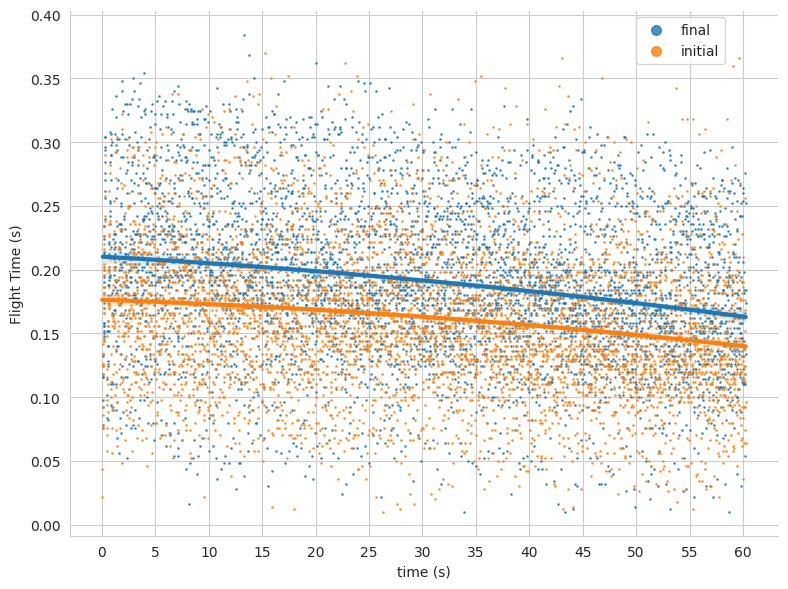

In [8]:
i=0
sns.set_style("whitegrid")
sns.lmplot(melt_df_list_timed[i].drop(melt_df_list_timed[i].loc[melt_df_list_timed[i].val>0.4].index),
           x='time', y='val', hue='Test', order = 2, x_ci='sd', legend=False,
           scatter_kws={"s": 0.75}, line_kws={"lw": 3},
           height=6, aspect=1.33).set(xticks=range(0, 65, 5))
plt.legend(loc=[0.8,0.9], markerscale=8)
plt.xlabel('time (s)')
plt.ylabel(dict[i])
#plt.savefig(dict[i]+' regression.svg')

Text(0, 0.5, 'Flight Time (s)')

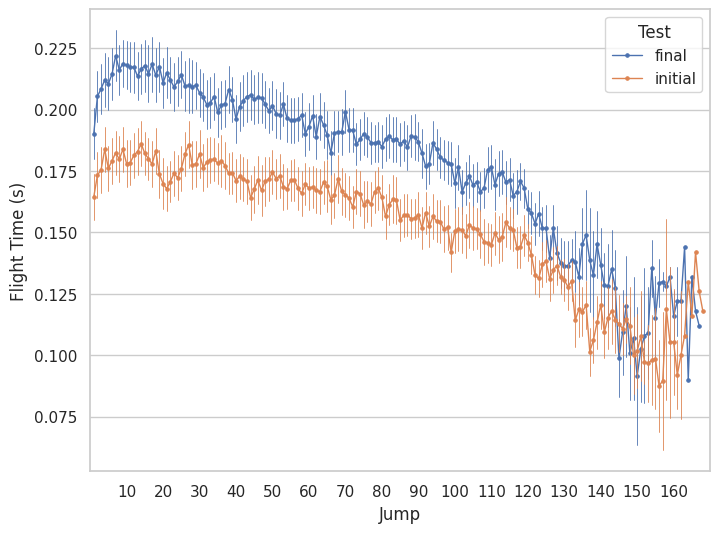

In [9]:
# Cannot use time because the function will attempt to aggregate all combinations, because time varies
# However NJump does not, so it can be aggregated
i=0
sns.set(rc={"figure.figsize":(8,6)})
sns.set_style("whitegrid")
sns.pointplot(melt_df_list_timed[i].drop(melt_df_list_timed[i].loc[melt_df_list_timed[i].val>0.4].index),
              x='Jump', y='val', hue='Test',
              estimator='mean', errorbar='se', legend=True, lw = 1,
              err_kws={'linewidth': 0.6}).set(xticks=range(-1, 170, 10))
# plt.xticks(ticks=[], labels=[])
plt.ylabel(dict[i])
#plt.savefig(dict[i]+' mean.svg')

In [41]:
dict2

{0: 'timp in aer (s)',
 1: 'timp contact (s)',
 2: 'inaltime (m)',
 3: 'putere (W/Kg)',
 4: 'viteza (sarituri/s)',
 5: 'IFR (m/s)',
 8: 'distanta picioare (mm)',
 10: 'distanta deviere (cm)'}

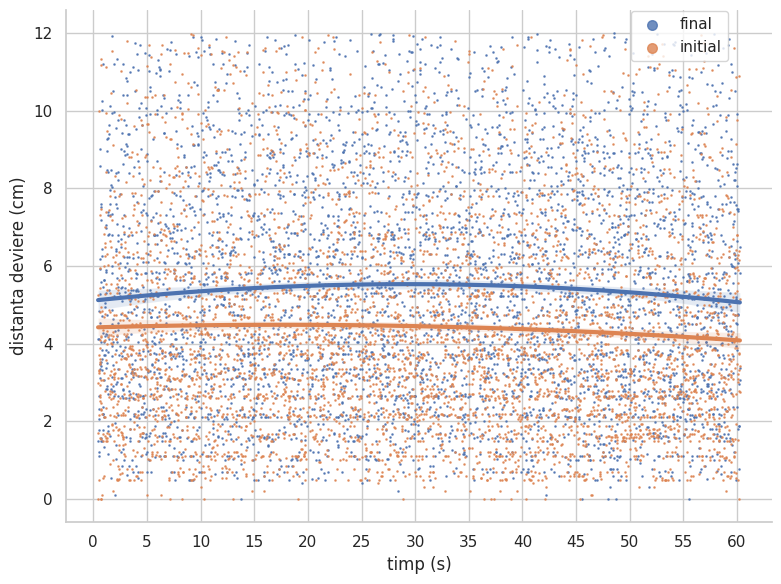

In [ ]:
i=10
sns.set_style("whitegrid")
sns.lmplot(melt_df_list_timed[i].drop(melt_df_list_timed[i].loc[melt_df_list_timed[i].val>12].index),
           x='time', y='val', hue='Test', order = 2, x_ci='sd', legend=False,
           scatter_kws={"s": 0.75}, line_kws={"lw": 3},
           height=6, aspect=1.33).set(xticks=range(0, 65, 5))
plt.legend(loc=[0.8,0.9], markerscale=8)
plt.xlabel('timp (s)')
plt.ylabel(dict2[i])
# plt.savefig(dict2[i]+' - regresie.svg')
# plt.savefig('putere - regresie.svg')
# plt.savefig('viteza - regresie.svg')
# plt.savefig('IFR - regresie.svg')

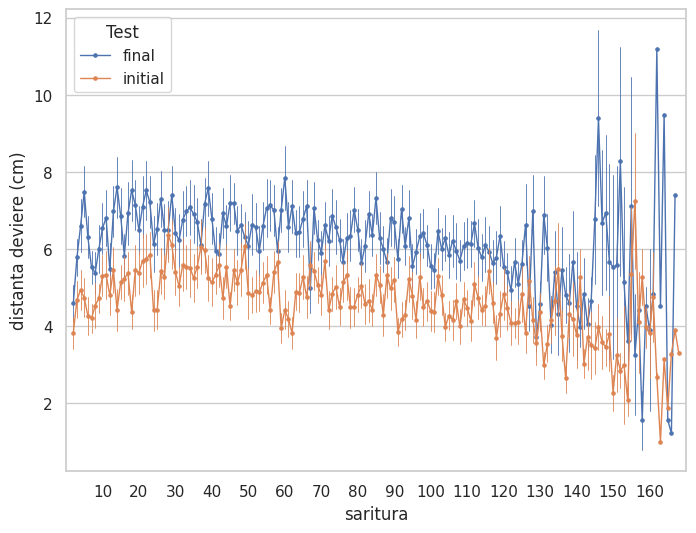

In [ ]:
# Cannot use time because the function will attempt to aggregate all combinations, because time varies
# However NJump does not, so it can be aggregated
i=10
sns.set(rc={"figure.figsize":(8,6)})
sns.set_style("whitegrid")
sns.pointplot(melt_df_list_timed[i].drop(melt_df_list_timed[i].loc[melt_df_list_timed[i].val>20].index),
              x='Jump', y='val', hue='Test',
              estimator='mean', errorbar='se', legend=True, lw = 1,
              err_kws={'linewidth': 0.6}).set(xticks=range(-1, 170, 10))
plt.xlabel('saritura')
# plt.xticks(ticks=[], labels=[])
plt.ylabel(dict2[i])
# plt.savefig(dict2[i]+' - medie.svg')
# plt.savefig('putere - medie.svg')
# plt.savefig('viteza - medie.svg')
# plt.savefig('IFR - medie.svg')